# Floating-Basis Code Optimization

Reproducible verification notebook for the floating-basis bosonic-code
optimization pipeline now living in `coherax`. Two procedures:

1. **Entanglement-fidelity (`F_e`)** &mdash; jointly optimize an encoder and a CPTP decoder against the pure-loss channel.
2. **Coherent-information (`I_c`)** &mdash; optimize only the encoder; `I_c` is decoder-independent and measures the intrinsic channel quality.

Everything is computed in the coherent-state basis (no Fock truncation in the optimization loop). This notebook uses a small **verification budget** (2 gammas, ~5 restarts each, short scans) so it finishes in a few minutes. Crank `RESTARTS` / `STEPS_*` up for publication-quality numbers.

## 1. Setup

In [1]:
import time

import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from coherax import (
    optimize_Fe_floating,
    optimize_Ic_floating,
    encode_logical_kets,
    coherent_information_pureloss,
    entanglement_fidelity_pureloss,
    nbar_logical,
)

## 2. Method summary

**Encoder.** A logical qubit ($D=2$) is encoded into a superposition of $N_C$ coherent states. The encoder is parametrized by an unconstrained matrix $X \in \mathbb{C}^{N_C \times D}$ and a displacement vector $d \in \mathbb{C}^{N_C}$. The Gram matrix $G_{ab} = \langle d_a | d_b \rangle$ gives the coefficient matrix

$$C \;=\; G^{-1/2}\,X\,(X^\dagger X)^{-1/2} \;\in\; \mathbb{C}^{N_C \times D},$$

satisfying $C^\dagger G C = \mathbb{1}_D$ algebraically. See `coherax.states.unitary_encoding_map`.

**Channel.** Pure loss at rate $\gamma$ is implemented as a beamsplitter ($\eta = 1 - \gamma$) with a vacuum environment, applied in the coherent basis without Fock truncation. See `coherax.states.beamsplit_full`.

**Decoder (for $F_e$ only).** A CPTP Kraus channel with $N_D$ Kraus operators is parametrized by $Z \in \mathbb{C}^{N_D \times D \times N_C}$; the constraint $\sum_i D_i^\dagger D_i = \mathbb{1}$ is enforced algebraically via $B = Z (Z^\dagger Z)^{-1/2}$.

**$F_e$ / $I_c$.** Both metrics are computed entirely in the coherent basis: `entanglement_fidelity_pureloss(X, d, Z, gamma)` and `coherent_information_pureloss(X, d, gamma)` from `coherax.fidelity`.

**Optimization.** Two-phase Adam restart loop. Phase 1 explores at a larger LR with a soft separation penalty $\lambda \sum_{a<b} \max(0, s_{\min}^2 - |d_a - d_b|^2)^2$ on the displacements (keeps the Gram matrix well-conditioned). Phase 2 refines from the Phase-1 solution at a smaller LR without the penalty. Restarts whose final metric is unphysical (NaN, $F_e > 1$, etc.) are rejected.

## 3. Verification-budget configuration

In [2]:
# Small budget so the notebook runs in a few minutes. Increase these for
# publication-quality numbers; the underlying optimizers can handle
# restarts in the hundreds and step counts in the tens of thousands.
GAMMAS    = [0.05, 0.15]
N_C       = 10
N_D       = 10
RESTARTS  = 5
STEPS_P1  = 2000
STEPS_P2  = 1000
MIN_SEP   = 1.0

print(f"Sweeping gammas={GAMMAS}, N_C={N_C}, restarts={RESTARTS}, steps={STEPS_P1}+{STEPS_P2}")

Sweeping gammas=[0.05, 0.15], N_C=10, restarts=5, steps=2000+1000


## 4. $F_e$ sweep

In [3]:
fe_runs = {}
t0 = time.time()
for gamma in GAMMAS:
    print(f"\n-- F_e | gamma = {gamma:.2f} --")
    res = optimize_Fe_floating(
        gamma=gamma, N_C=N_C, N_D=N_D, restarts=RESTARTS,
        steps_p1=STEPS_P1, steps_p2=STEPS_P2,
        lr_p1=5e-3, lr_p2=5e-4, sep_lam=0.5, min_sep=MIN_SEP,
        seed=int(round(gamma * 1000)) + 1, verbose=True,
    )
    fe_runs[gamma] = res
    print(f"   F_e = {res['Fe']:.6f}, nbar = {res['nbar']:.2f}")
print(f"\nTotal F_e sweep: {time.time()-t0:.1f}s")


-- F_e | gamma = 0.05 --


/opt/miniconda3/envs/coherax/lib/python3.11/site-packages/jax/_src/lax/lax.py:5377: ComplexWarning: Casting complex values to real discards the imaginary part
  x_bar = _convert_element_type(x_bar, x.aval.dtype, x.aval.weak_type)


  JIT compiled (gamma=0.050, N_C=10, N_D=10, restarts=5, steps=2000+1000)
    restart   1/5: best F_e = 0.940926, valid = 1
    restart   2/5: best F_e = 0.999386, valid = 2
    restart   3/5: best F_e = 0.999386, valid = 3
    restart   4/5: best F_e = 0.999386, valid = 4
    restart   5/5: best F_e = 0.999386, valid = 5
  done in   1.4s -- best F_e = 0.999386, valid = 5/5
   F_e = 0.999386, nbar = 2.70

-- F_e | gamma = 0.15 --
  JIT compiled (gamma=0.150, N_C=10, N_D=10, restarts=5, steps=2000+1000)
    restart   1/5: best F_e = 0.985317, valid = 1
    restart   2/5: best F_e = 0.991267, valid = 2
    restart   3/5: best F_e = 0.991267, valid = 3
    restart   4/5: best F_e = 0.991267, valid = 4
    restart   5/5: best F_e = 0.991267, valid = 5
  done in   1.4s -- best F_e = 0.991267, valid = 5/5
   F_e = 0.991267, nbar = 3.57

Total F_e sweep: 4.8s


## 5. $I_c$ sweep

In [4]:
ic_runs = {}
t0 = time.time()
for gamma in GAMMAS:
    print(f"\n-- I_c | gamma = {gamma:.2f} --")
    res = optimize_Ic_floating(
        gamma=gamma, N_C=N_C, restarts=RESTARTS,
        steps_p1=STEPS_P1, steps_p2=STEPS_P2,
        lr_p1=1e-2, lr_p2=1e-3, sep_lam=0.3, min_sep=MIN_SEP,
        seed=int(round(gamma * 1000)) + 7, verbose=True,
    )
    ic_runs[gamma] = res
    print(f"   I_c = {res['Ic']:.6f} qubits, nbar = {res['nbar']:.2f}")
print(f"\nTotal I_c sweep: {time.time()-t0:.1f}s")


-- I_c | gamma = 0.05 --
  JIT compiled (gamma=0.050, N_C=10, restarts=5, steps=2000+1000)
    restart   1/5: best I_c = 0.998644 q, valid = 1
    restart   2/5: best I_c = 0.998644 q, valid = 2
    restart   3/5: best I_c = 0.998644 q, valid = 3
    restart   4/5: best I_c = 0.998703 q, valid = 4
    restart   5/5: best I_c = 0.998703 q, valid = 5
  done in   1.6s -- best I_c = 0.998703 q, valid = 5/5
   I_c = 0.998703 qubits, nbar = 3.40

-- I_c | gamma = 0.15 --
  JIT compiled (gamma=0.150, N_C=10, restarts=5, steps=2000+1000)
    restart   1/5: best I_c = 0.970083 q, valid = 1
    restart   2/5: best I_c = 0.970486 q, valid = 2
    restart   3/5: best I_c = 0.970486 q, valid = 3
    restart   4/5: best I_c = 0.970764 q, valid = 4
    restart   5/5: best I_c = 0.970764 q, valid = 5
  done in   1.6s -- best I_c = 0.970764 q, valid = 5/5
   I_c = 0.970764 qubits, nbar = 4.02

Total I_c sweep: 4.4s


## 6. Summary table

In [5]:
print(f"{'gamma':>6s}  {'F_e':>10s}  {'I_c (q)':>10s}  {'nbar (F_e)':>10s}  {'nbar (I_c)':>10s}")
print("-" * 56)
for g in GAMMAS:
    fe_val   = fe_runs[g]['Fe']
    ic_val   = ic_runs[g]['Ic']
    nbar_fe  = fe_runs[g]['nbar']
    nbar_ic  = ic_runs[g]['nbar']
    print(f"{g:6.2f}  {fe_val:10.6f}  {ic_val:10.6f}  {nbar_fe:10.2f}  {nbar_ic:10.2f}")

 gamma         F_e     I_c (q)  nbar (F_e)  nbar (I_c)
--------------------------------------------------------
  0.05    0.999386    0.998703        2.70        3.40
  0.15    0.991267    0.970764        3.57        4.02


## 7. Plots

### 7.1 $F_e$ and $I_c$ vs $\gamma$

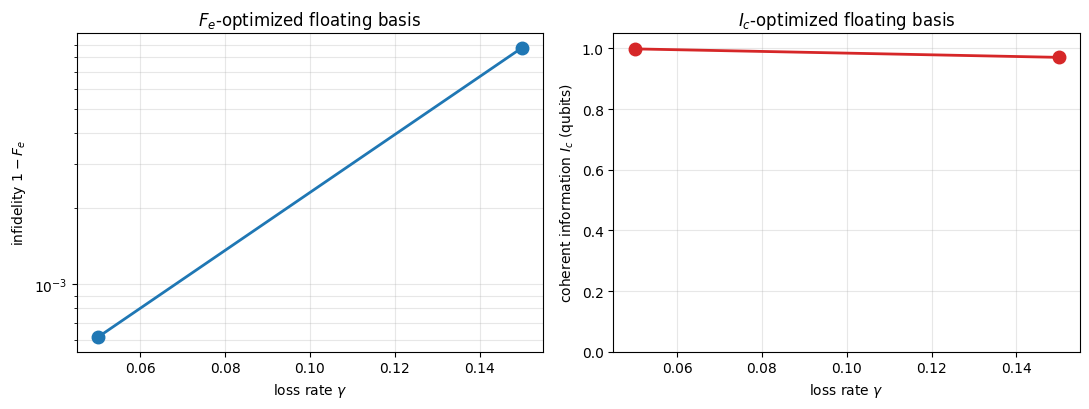

In [6]:
fig, (ax_fe, ax_ic) = plt.subplots(1, 2, figsize=(11, 4.2))

gs = sorted(fe_runs.keys())
ax_fe.semilogy(gs, [1 - fe_runs[g]['Fe'] for g in gs], 'o-', lw=2, ms=9)
ax_fe.set_xlabel(r'loss rate $\gamma$')
ax_fe.set_ylabel(r'infidelity $1 - F_e$')
ax_fe.set_title(r'$F_e$-optimized floating basis')
ax_fe.grid(True, which='both', alpha=0.3)

gs = sorted(ic_runs.keys())
ax_ic.plot(gs, [ic_runs[g]['Ic'] for g in gs], 'o-', lw=2, ms=9, color='C3')
ax_ic.set_xlabel(r'loss rate $\gamma$')
ax_ic.set_ylabel(r'coherent information $I_c$ (qubits)')
ax_ic.set_title(r'$I_c$-optimized floating basis')
ax_ic.set_ylim(0.0, 1.05)
ax_ic.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 7.2 Convergence curves

Running-max envelope of the best-restart loss curve, showing the cumulative best metric value seen during optimization. Adam can step into Gram-collapse regions transiently and then recover, so the raw curve is noisy; the running max isolates the actual progress.

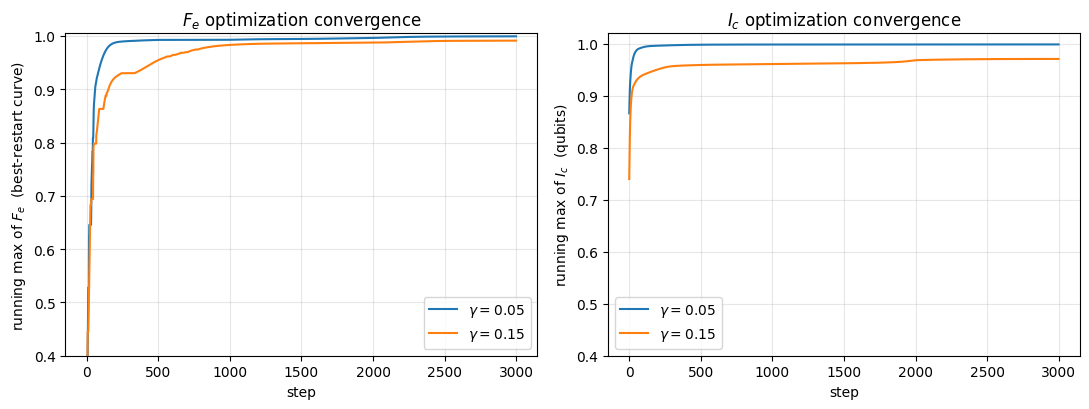

In [9]:
def running_max(x):
    return np.maximum.accumulate(np.where(np.isfinite(x), x, -np.inf))

fig, (ax_fe, ax_ic) = plt.subplots(1, 2, figsize=(11, 4.2))

for g in sorted(fe_runs.keys()):
    if fe_runs[g]['curve'] is None:
        continue
    ax_fe.plot(running_max(-np.asarray(fe_runs[g]['curve'])), label=fr'$\gamma={g:.2f}$', lw=1.5)
ax_fe.set_xlabel('step')
ax_fe.set_ylabel(r'running max of $F_e$  (best-restart curve)')
ax_fe.set_title(r'$F_e$ optimization convergence')
ax_fe.grid(True, alpha=0.3)
ax_fe.legend()
ax_fe.set_ylim(0.4, 1.005)

for g in sorted(ic_runs.keys()):
    if ic_runs[g]['curve'] is None:
        continue
    ax_ic.plot(running_max(-np.asarray(ic_runs[g]['curve'])), label=fr'$\gamma={g:.2f}$', lw=1.5)
ax_ic.set_xlabel('step')
ax_ic.set_ylabel(r'running max of $I_c$  (qubits)')
ax_ic.set_title(r'$I_c$ optimization convergence')
ax_ic.grid(True, alpha=0.3)
ax_ic.legend()
ax_ic.set_ylim(0.4, 1.02)

plt.tight_layout()
plt.show()

### 7.3 Phase-space scatter of optimized $|d_a|$ positions

Marker size $\propto |c_0|^2 + |c_1|^2$ (the encoder coefficient magnitudes summed over the two logical basis states).

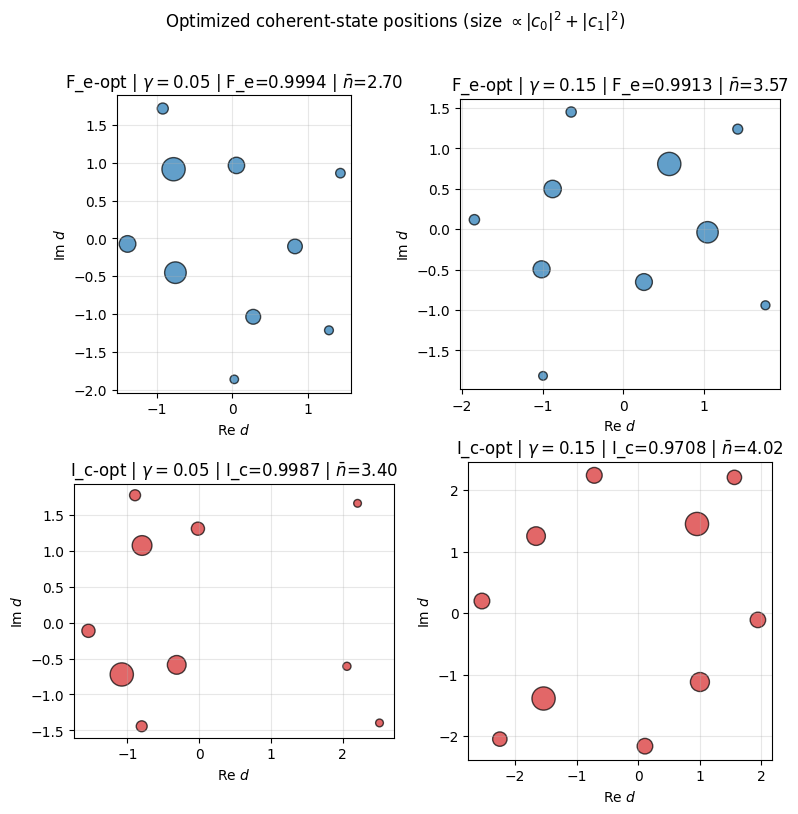

In [7]:
fig, axes = plt.subplots(2, len(GAMMAS), figsize=(4 * len(GAMMAS), 8))
if len(GAMMAS) == 1:
    axes = axes.reshape(2, 1)

for col, gamma in enumerate(GAMMAS):
    for row, (runs, title_pref, c) in enumerate([
        (fe_runs, 'F_e', 'C0'),
        (ic_runs, 'I_c', 'C3'),
    ]):
        ax = axes[row, col]
        res = runs[gamma]
        if res['X'] is None:
            ax.set_axis_off(); continue
        ket0, ket1 = encode_logical_kets(res['X'], res['d'])
        weights = np.asarray(jnp.abs(ket0.cs) ** 2 + jnp.abs(ket1.cs) ** 2)
        sizes = 30 + 250 * weights / (weights.max() + 1e-12)
        d = np.asarray(res['d'])
        metric = res['Fe'] if title_pref == 'F_e' else res['Ic']
        ax.scatter(d.real, d.imag, s=sizes, c=c, alpha=0.7, edgecolors='k')
        ax.set_title(fr'{title_pref}-opt | $\gamma={gamma:.2f}$ | {title_pref}={metric:.4f} | $\bar n$={res["nbar"]:.2f}')
        ax.set_xlabel(r'Re $d$')
        ax.set_ylabel(r'Im $d$')
        ax.set_aspect('equal', 'box')
        ax.grid(True, alpha=0.3)

plt.suptitle(r'Optimized coherent-state positions (size $\propto |c_0|^2 + |c_1|^2$)', y=1.01)
plt.tight_layout()
plt.show()

### 7.4 Wigner functions of optimized logical states

Wigner-function plots of $|0_L\rangle$ and $|1_L\rangle$ for each $\gamma$, both objectives. Uses `dynamiqs.plot.wigner` on the Fock-basis density matrix of the encoded ket. Custom divergent colormap with $|W|_{\max} = 2/\pi$.

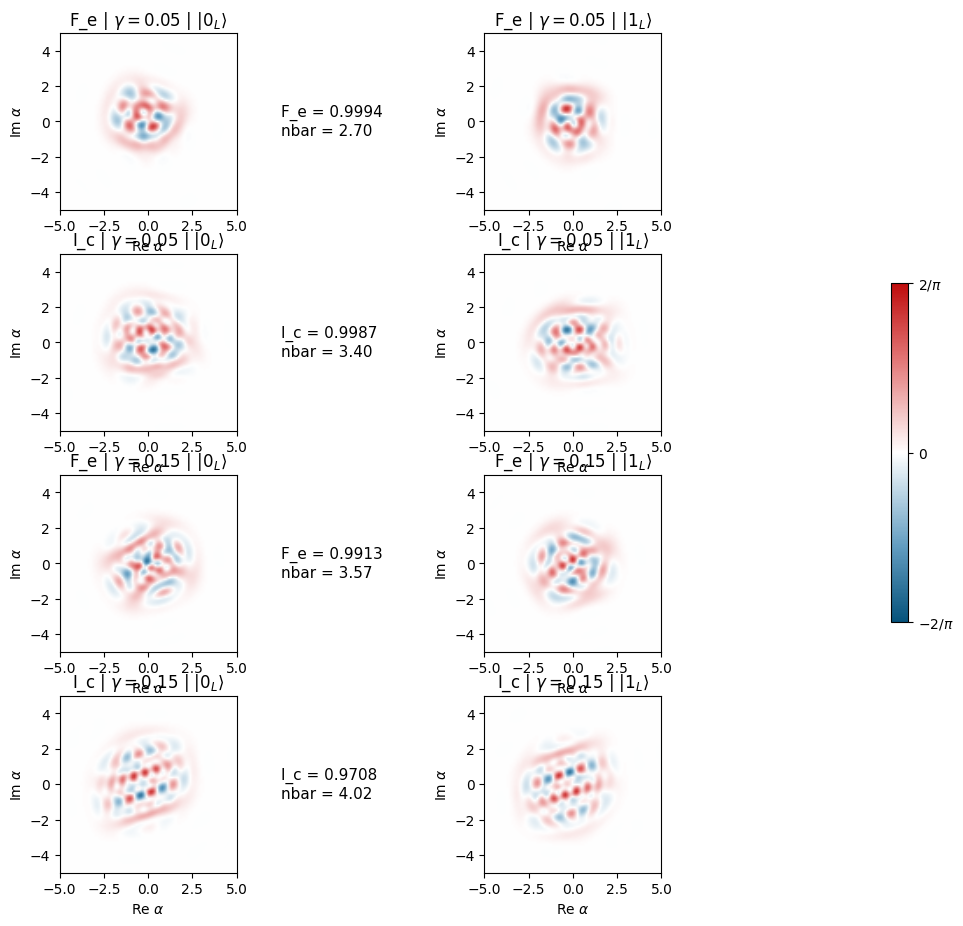

In [8]:
import dynamiqs as dq
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, LinearSegmentedColormap

VMAX = 2.0 / np.pi
WIGNER_CMAP = LinearSegmentedColormap.from_list(
    'wigner_custom',
    [
        (0.000, '#05527B'),
        (0.225, '#639DC1'),
        (0.500, '#FFFFFF'),
        (0.775, '#E27777'),
        (1.000, '#BF0C0C'),
    ],
)

def _state_qarray(ket):
    return dq.asqarray(ket.to_fock_basis())

fig, axes = plt.subplots(2 * len(GAMMAS), 4, figsize=(11, 5.5 * len(GAMMAS)),
                         squeeze=False)
row = 0
for gamma in GAMMAS:
    for label, runs in [('F_e', fe_runs), ('I_c', ic_runs)]:
        res = runs[gamma]
        if res['X'] is None:
            for col in range(4):
                axes[row, col].set_axis_off()
            row += 1
            continue
        ket0, ket1 = encode_logical_kets(res['X'], res['d'])
        qs = [_state_qarray(ket0), _state_qarray(ket1)]
        metric = res['Fe'] if label == 'F_e' else res['Ic']
        for col, q in enumerate(qs):
            ax = axes[row, col * 2]
            dq.plot.wigner(q, ax=ax, xmax=5.0, npixels=101,
                           vmax=VMAX, cmap=WIGNER_CMAP, colorbar=False)
            ax.set_aspect('equal')
            ax.set_title(fr'{label} | $\gamma={gamma:.2f}$ | $|{col}_L\rangle$')
            ax.set_xlabel('Re $\\alpha$')
            ax.set_ylabel('Im $\\alpha$')
            # Hide the adjacent column to fit 2 plots in a 4-column grid
            axes[row, col * 2 + 1].set_axis_off()
        # Annotate to the right
        axes[row, 1].text(0.05, 0.5,
                          f"{label} = {metric:.4f}\nnbar = {res['nbar']:.2f}",
                          fontsize=11, va='center')
        axes[row, 3].set_axis_off()
        row += 1

sm = ScalarMappable(norm=Normalize(vmin=-VMAX, vmax=VMAX), cmap=WIGNER_CMAP)
cbar = fig.colorbar(sm, ax=axes.ravel().tolist(),
                    shrink=0.4, pad=0.02, fraction=0.025,
                    ticks=[-VMAX, 0.0, VMAX])
cbar.ax.set_yticklabels([r'$-2/\pi$', '$0$', r'$2/\pi$'])
plt.show()

## 8. Sanity checks

Verify (i) the encoder isometry $C^\dagger G C = I_D$ holds to numerical precision on every optimized result, and (ii) that recomputing $F_e$ / $I_c$ from the saved parameters reproduces the optimization-loop value.

In [10]:
from coherax.linalg_utils import coherent_overlap, dag
from coherax.states import unitary_encoding_map

print(f"{'gamma':>6s}  {'objective':>10s}  {'|C^dag G C - I|':>16s}  {'|reproduce|':>12s}")
print('-' * 56)
for gamma in GAMMAS:
    for label, runs in [('F_e', fe_runs), ('I_c', ic_runs)]:
        res = runs[gamma]
        if res['X'] is None:
            continue
        X, d = res['X'], res['d']
        A = d.shape[0]
        psi_0 = jnp.array([1.0+0j, 0.0+0j]); psi_1 = jnp.array([0.0+0j, 1.0+0j])
        c0 = unitary_encoding_map(X, d, psi_0); c1 = unitary_encoding_map(X, d, psi_1)
        C = jnp.stack([c0, c1], axis=1)
        G = coherent_overlap(d.reshape(A, 1), d.reshape(1, A))
        iso = float(jnp.linalg.norm(dag(C) @ G @ C - jnp.eye(2)))
        if label == 'F_e':
            metric_recomp = float(entanglement_fidelity_pureloss(X, d, res['Z'], gamma))
            metric_stored = res['Fe']
        else:
            metric_recomp = float(coherent_information_pureloss(X, d, gamma))
            metric_stored = res['Ic']
        diff = abs(metric_recomp - metric_stored)
        print(f'{gamma:6.2f}  {label:>10s}  {iso:16.3e}  {diff:12.2e}')

 gamma   objective   |C^dag G C - I|   |reproduce|
--------------------------------------------------------
  0.05         F_e         4.298e-15      0.00e+00
  0.05         I_c         2.324e-14      0.00e+00
  0.15         F_e         4.067e-14      0.00e+00
  0.15         I_c         1.957e-15      0.00e+00
